In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob

In [2]:
def correct_encoding(measured_image):
    return measured_image / 16 +1

In [3]:
#Creation of Difference Image
with fits.open('Lab1/bias_images/Bias_Seamus_Derryck-0001.fit') as hdul_bias1, fits.open('Lab1/bias_images/Bias_Seamus_Derryck-0001.fit') as hdul_bias2:
    
    bias1_data = hdul_bias1[0].data
    bias2_data = hdul_bias2[0].data
    
    header = hdul_bias1[0].header

diff_data = bias1_data - bias2_data

hdu_diff = fits.PrimaryHDU(data=diff_data, header=header)
hdu_diff.writeto('difference_image.fits', overwrite=True)


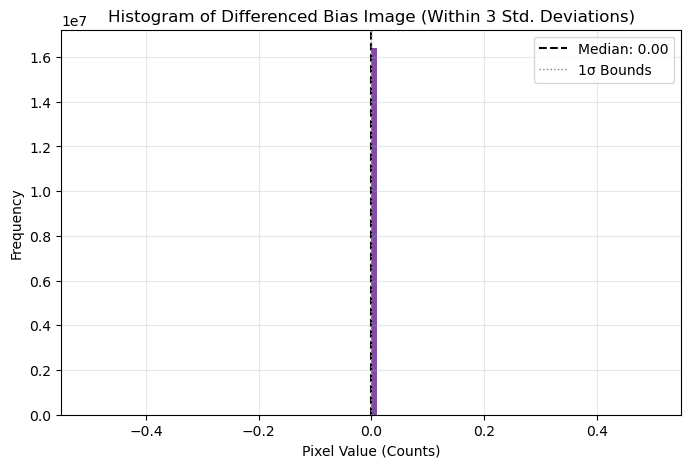

In [4]:
#Plotting of Difference Histogram
with fits.open('difference_image.fits') as hdul:
    diff_data = hdul[0].data

flat_data = diff_data.flatten()
flat_data = flat_data[~np.isnan(flat_data)]

median = np.median(flat_data)
std_dev = np.std(flat_data)

xmin = median - 3 * std_dev
xmax = median + 3 * std_dev

plt.figure(figsize=(8, 5))
plt.hist(flat_data, bins=100, range=(xmin, xmax), color='indigo', histtype='stepfilled', alpha=0.7)

plt.axvline(median, color='black', linestyle='dashed', linewidth=1.5, label=f'Median: {median:.2f}')
plt.axvline(median - std_dev, color='gray', linestyle='dotted', linewidth=1, label=f'1σ Bounds')
plt.axvline(median + std_dev, color='gray', linestyle='dotted', linewidth=1)

plt.title('Histogram of Differenced Bias Image (Within 3 Std. Deviations)')
plt.xlabel('Pixel Value (Counts)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [5]:
#Calculation of Read Noise

sigma_diff = np.std(diff_data)
read_noise = sigma_diff / np.sqrt(2)

In [6]:
#Bias Image Calculations
bias_files = glob.glob('Lab1/bias_images/*.fit')

#Correcting each bias image
corrected_array = []
for bias_path in bias_files:
    with fits.open(bias_path, mode='update') as foo:
        measured_image = foo[0].data

        if measured_image is not None:
            corrected_image = correct_encoding(measured_image)
            foo.data = corrected_image
            corrected_array.append(foo.data)

Text(0.5, 1.0, 'Average Bias Image: QHY 163M CMOS')

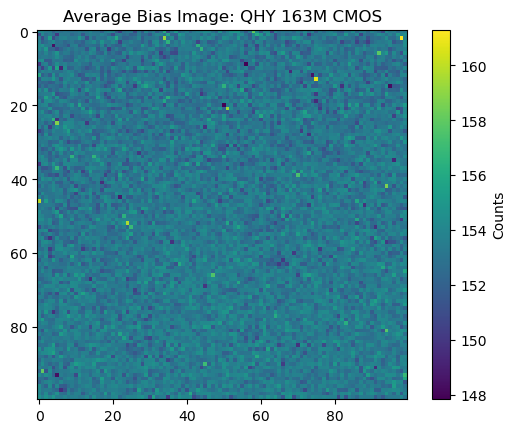

In [7]:
#Taking the average/median of the average of the now corrected images
bias_array = np.array(corrected_array)
bias_avg = np.mean(bias_array, axis=0)
bias_avg_median = np.median(bias_avg)

plt.imshow(bias_avg[0:100, 0:100])
plt.colorbar(label ='Counts')
plt.title('Average Bias Image: QHY 163M CMOS')

Text(0.5, 1.0, 'Average Dark Image: QHY 163M CMOS')

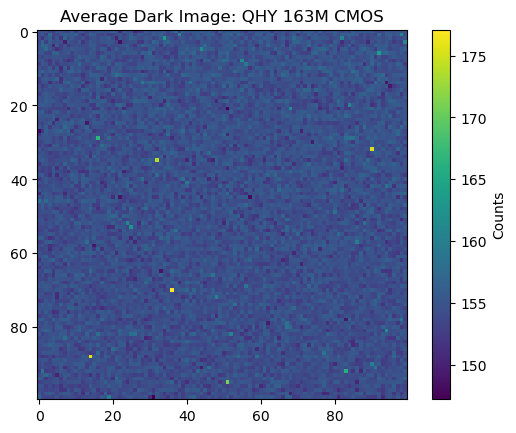

In [8]:
#Dark Image Calculations(Time 1)
dark1_files = glob.glob('Lab1/dark_time-1/*.fit')

#Correcting each dark image
corrected_array2 = []
for dark_path in dark1_files:
    with fits.open(dark_path, mode='update') as foo:
        measured_image = foo[0].data

        if measured_image is not None:
            corrected_image = correct_encoding(measured_image)
            foo.data = corrected_image
            corrected_array2.append(foo.data)

#Taking the average/median of the average of the now corrected images
dark1_array = np.array(corrected_array2)
dark1_avg = np.mean(dark1_array, axis=0)
dark1_avg_median = np.median(dark1_avg)

plt.imshow(dark1_avg[0:100, 0:100])
plt.colorbar(label ='Counts')
plt.title('Average Dark Image: QHY 163M CMOS')

Text(0.5, 1.0, 'Average Dark Image: QHY 163M CMOS')

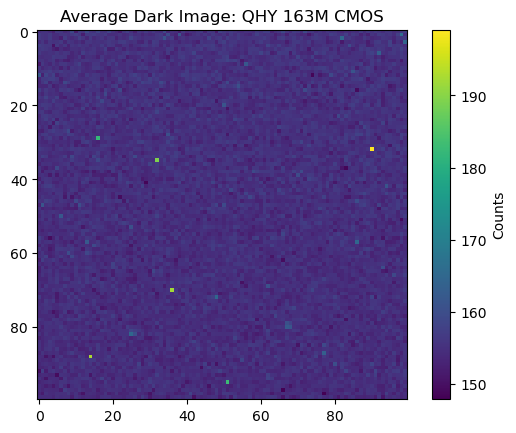

In [9]:
#Dark Image Calculations(Time 2)
dark2_files = glob.glob('Lab1/dark_time-2/*.fit')

#Correcting each dark image
corrected_array3 = []
for dark_path in dark2_files:
    with fits.open(dark_path, mode='update') as foo:
        measured_image = foo[0].data

        if measured_image is not None:
            corrected_image = correct_encoding(measured_image)
            foo.data = corrected_image
            corrected_array3.append(foo.data)

#Taking the average/median of the average of the now corrected images
dark2_array = np.array(corrected_array3)
dark2_avg = np.mean(dark2_array, axis=0)
dark2_avg_median = np.median(dark2_avg)

plt.imshow(dark2_avg[0:100, 0:100])
plt.colorbar(label ='Counts')
plt.title('Average Dark Image: QHY 163M CMOS')

Text(0.5, 1.0, 'Average Dark Image: QHY 163M CMOS')

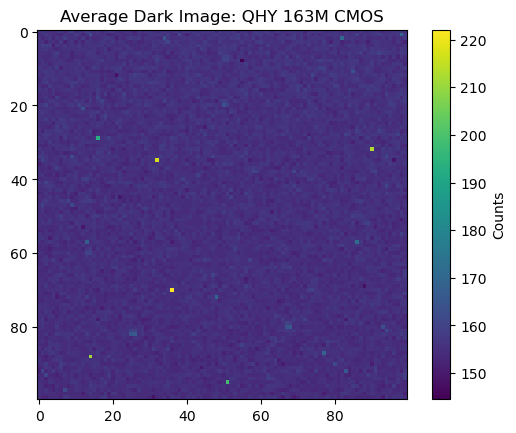

In [10]:
#Dark Image Calculations(Time 3)
dark3_files = glob.glob('Lab1/dark_time-3/*.fit')

#Correcting each dark image
corrected_array4 = []
for dark_path in dark3_files:
    with fits.open(dark_path, mode='update') as foo:
        measured_image = foo[0].data

        if measured_image is not None:
            corrected_image = correct_encoding(measured_image)
            foo.data = corrected_image
            corrected_array4.append(foo.data)

#Taking the average/median of the average of the now corrected images
dark3_array = np.array(corrected_array4)
dark3_avg = np.mean(dark3_array, axis=0)
dark3_avg_median = np.median(dark3_avg)

plt.imshow(dark3_avg[0:100, 0:100])
plt.colorbar(label ='Counts')
plt.title('Average Dark Image: QHY 163M CMOS')

Text(0.5, 1.0, 'Average Normalized Twilight Flat: QHY 163M CMOS')

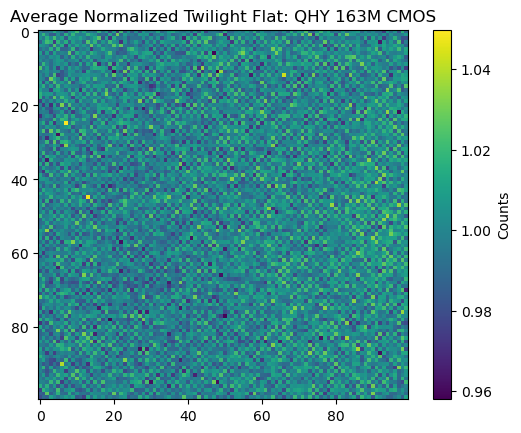

In [12]:
#Twilight Flat Calculations(
flat_files = glob.glob('Lab1/select_flats/*.fit')

#Correcting and normalizing each flat image
normal_stack = []
for flat_path in flat_files:
    with fits.open(flat_path, mode='update') as foo:
        measured_image = foo[0].data

        if measured_image is not None:
            corrected_image = correct_encoding(measured_image)
            z_i = corrected_image - bias_avg
            z_i_med = np.median(z_i)
            z_i_normal = z_i / z_i_med
            normal_stack.append(z_i_normal)

#Combining all corrected and normalized flats
final_normal_twi = np.median(normal_stack, axis=0)

plt.imshow(final_normal_twi[0:100, 0:100])
plt.colorbar(label ='Counts')
plt.title('Average Normalized Twilight Flat: QHY 163M CMOS')

<function matplotlib.pyplot.show(close=None, block=None)>

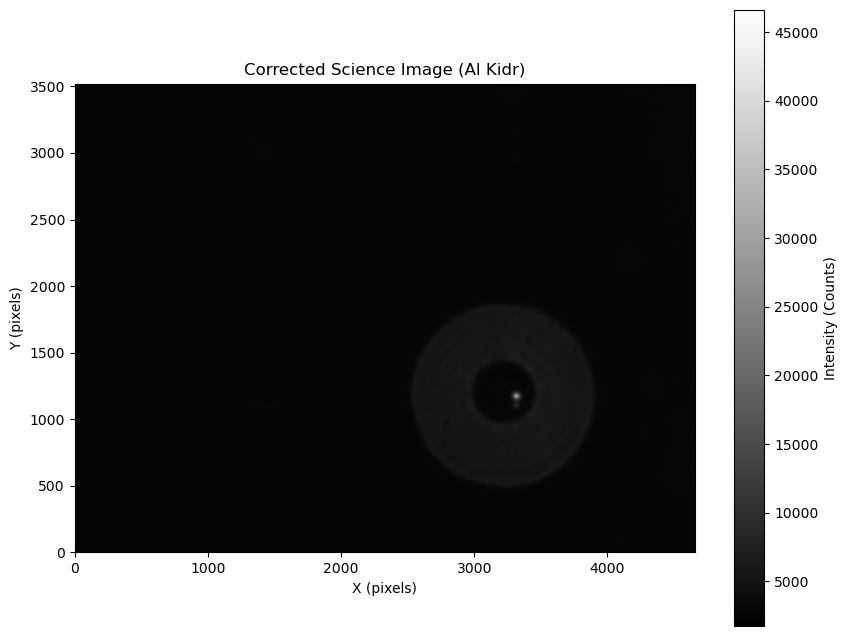

In [26]:
#Creation of Calibrated Science Image 1 (Al Kidr 1)
with fits.open('Lab1/AlKidr_Seamus_Derryck-0001.fit') as hdul:
        S_i = hdul[0].data.astype(float)
        
        d = dark1_avg
        
        b = bias_avg
        
        flat = final_normal_twi

calibrated_data_1 = (S_i - d - b) / flat

hdu = fits.PrimaryHDU(calibrated_data_1)
hdu.writeto('AlKidr_Corrected_1.fits', overwrite=True)

plt.figure(figsize=(10,8))
img = plt.imshow(calibrated_data_1, cmap = 'grey', origin='lower')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.colorbar(img, label = 'Intensity (Counts)')
plt.title('Corrected Science Image (Al Kidr)')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

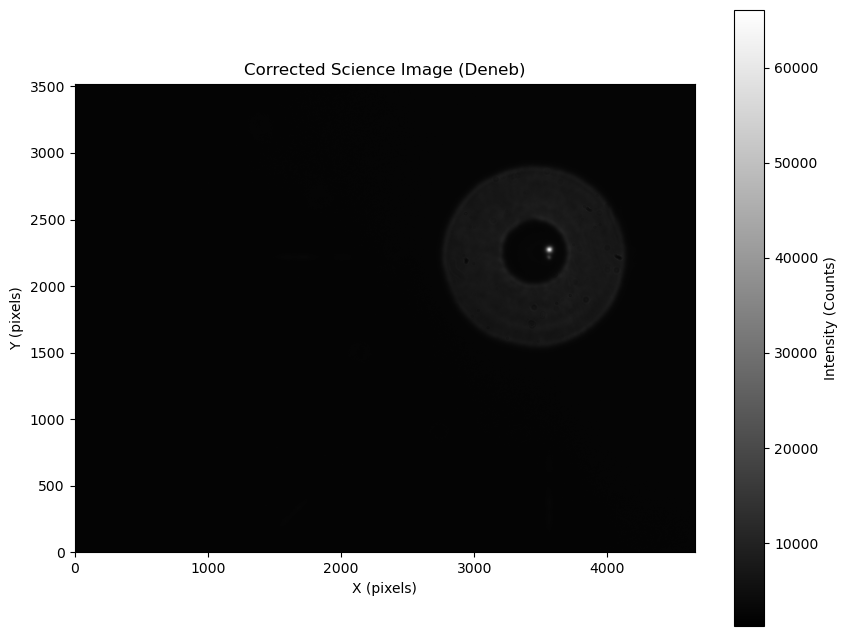

In [27]:
#Creation of Calibrated Science Image 2 (Deneb 1)
with fits.open('Lab1/Deneb_Seamus_Derryck-0001.fit') as hdul:
        S_i = hdul[0].data.astype(float)
        
        d = dark1_avg
        
        b = bias_avg
        
        flat = final_normal_twi

calibrated_data_2 = (S_i - d - b) / flat

hdu = fits.PrimaryHDU(calibrated_data_1)
hdu.writeto('Deneb_Corrected_1.fits', overwrite=True)

plt.figure(figsize=(10,8))
img = plt.imshow(calibrated_data_2, cmap = 'grey', origin='lower')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.colorbar(img, label = 'Intensity (Counts)')
plt.title('Corrected Science Image (Deneb)')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

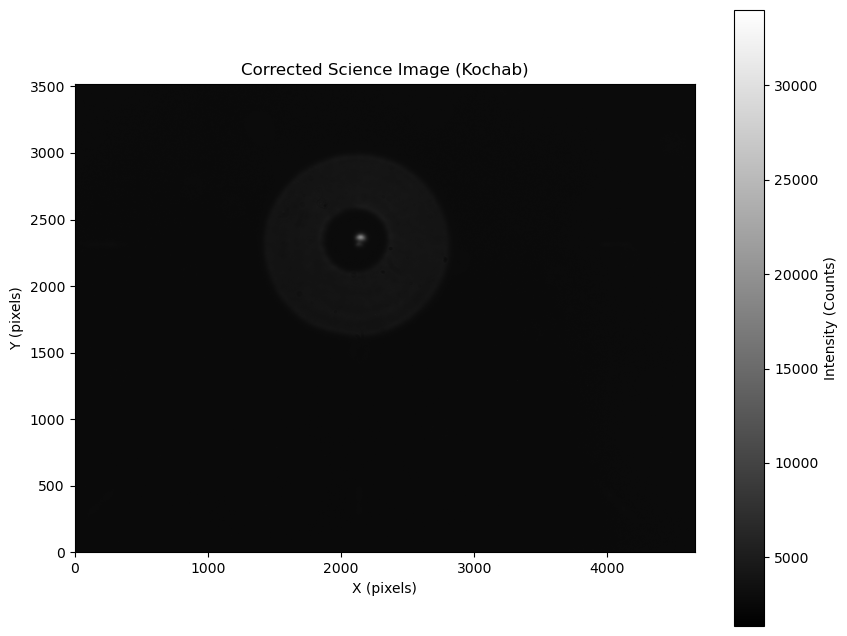

In [28]:
#Creation of Calibrated Science Image 2 (Kochab 1)
with fits.open('Lab1/Kochab_Seamus_Derryck-0001.fit') as hdul:
        S_i = hdul[0].data.astype(float)
        
        d = dark1_avg
        
        b = bias_avg
        
        flat = final_normal_twi

calibrated_data_3 = (S_i - d - b) / flat

hdu = fits.PrimaryHDU(calibrated_data_1)
hdu.writeto('Kochab_Corrected_1.fits', overwrite=True)

plt.figure(figsize=(10,8))
img = plt.imshow(calibrated_data_3, cmap = 'grey', origin='lower')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.colorbar(img, label = 'Intensity (Counts)')
plt.title('Corrected Science Image (Kochab)')

plt.show